In [4]:
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# load the dataset directly from keras
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

#  flatten the images into 1D arrays of 784 pixels
X_train_flat = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_flat = X_test_full.reshape(X_test_full.shape[0], -1)


# Using stratify makes sure we keep an even mix of all the digits (0-9)
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_flat, y_train_full, train_size=10000, stratify=y_train_full, random_state=42
)

# grab a smaller chunk of the test set just to keep things proportional
X_test_sub, _, y_test_sub, _ = train_test_split(
    X_test_flat, y_test_full, train_size=2000, stratify=y_test_full, random_state=42
)

#using standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub)
X_test_scaled = scaler.transform(X_test_sub)

In [2]:
# Setting up the parameters we want to test
# trying both linear and rbf kernels, alongside different C values for hard/soft margins
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Initialize the base SVM
svm_base = SVC()

# We use GridSearchCV to automatically run 3-fold cross-validation across all our parameter combos
print("Starting the grid search")
grid_search = GridSearchCV(svm_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit the models on our scaled, subset data
grid_search.fit(X_train_scaled, y_train_sub)

#  the best combination turned out to be
print(f"Best Parameters Found: {grid_search.best_params_}")

Starting the grid search... this might take a minute depending on your hardware.
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters Found: {'C': 10, 'kernel': 'rbf'}


Final Test Accuracy: 0.9515


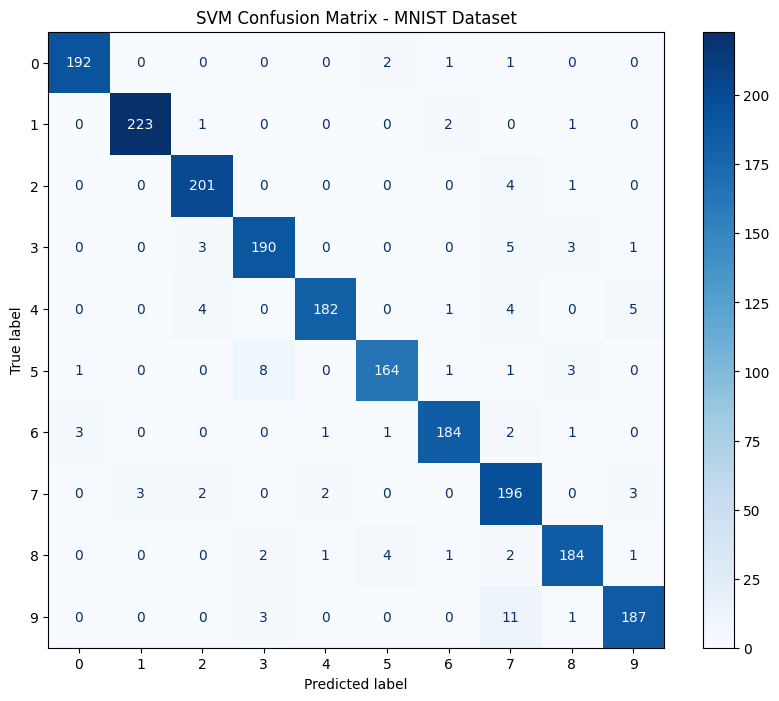

In [3]:
# Grab the best model from our grid search
best_svm = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_svm.predict(X_test_scaled)

# Calculate and print the final accuracy score
final_accuracy = accuracy_score(y_test_sub, y_pred)
print(f"Final Test Accuracy: {final_accuracy:.4f}")

# visualize where the model gets confused
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay.from_estimator(
    best_svm,
    X_test_scaled,
    y_test_sub,
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title('SVM Confusion Matrix - MNIST Dataset')
plt.show()